In [ ]:
# Opens up dialogue box to pick a file to upload. Use to upload the zip data.
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [1]:
import zipfile
import io
import pandas as pd

# TO DO
# X double check user vs developer centric features from paper
# X double check validation and training/testing split
# X do evaluation for BOTH user and developer centered
# Explaining misclassifications with llm
# remove unnnamed index
# X compare earlier dataset with corrected dataset
# make colab copy to folderr
# push progress to github repo
# do google slides for excelformer, add to google drive

# Read the uploaded CSV file
# csv_file_name = next(iter(uploaded.keys()))
# df1 = pd.read_csv(io.StringIO(uploaded[csv_file_name].decode('utf-8')), index_col=0)
df = pd.read_csv('/content/sample_data/corrected_permacts.csv')
# df2 = pd.read_csv('/content/sample_data/mergedfeaturessep102.csv')

print("\nDataset Info:")
print(df.info())

# Get all feature names
all_features = df.columns.tolist()
all_features.remove('status')  # Remove the target variable from features
all_features.remove('pkgname')  # Remove the package name as it's not a feature

# Define features for user-centered and developer-centered models
user_centered_features = all_features.copy()
developer_centered_features = [f for f in all_features if f not in [
    'FourStarRatings', 'ThreeStarRatings', 'FiveStarRatings',
    'OneStarRatings', 'TwoStarRatings', 'ReviewsAverage',
    'LenWhatsNew', 'max_downloads_log', 'days_since_last_update', 'LastUpdated'
]]

print("\nNumber of features:")
print(f"User-centered: {len(user_centered_features)}")
print(f"Developer-centered: {len(developer_centered_features)}")

for feature in user_centered_features:
    print(f'user feature {feature}')

for feature in developer_centered_features:
    print(f"dev feature {feature}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/corrected_permacts.csv'


Original Dataset Info:
Total rows: 755305
NaN in status: 1

Corrected Dataset Info:
Total rows: 870514
NaN in status: 0

Feature verification:
Total features: 47
'status' in features: False
First few features: ['DevRegisteredDomain', 'LenDescription', 'LenWhatsNew', 'ReviewsAverage', 'CurrentVersion']


<ipython-input-3-9916433cf12f>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].fillna(df_clean[col].median())
<ipython-input-3-9916433cf12f>:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


User-centered Model AUC on test (original) set: 0.730
User-centered Model AUC on test (corrected) set: 0.731


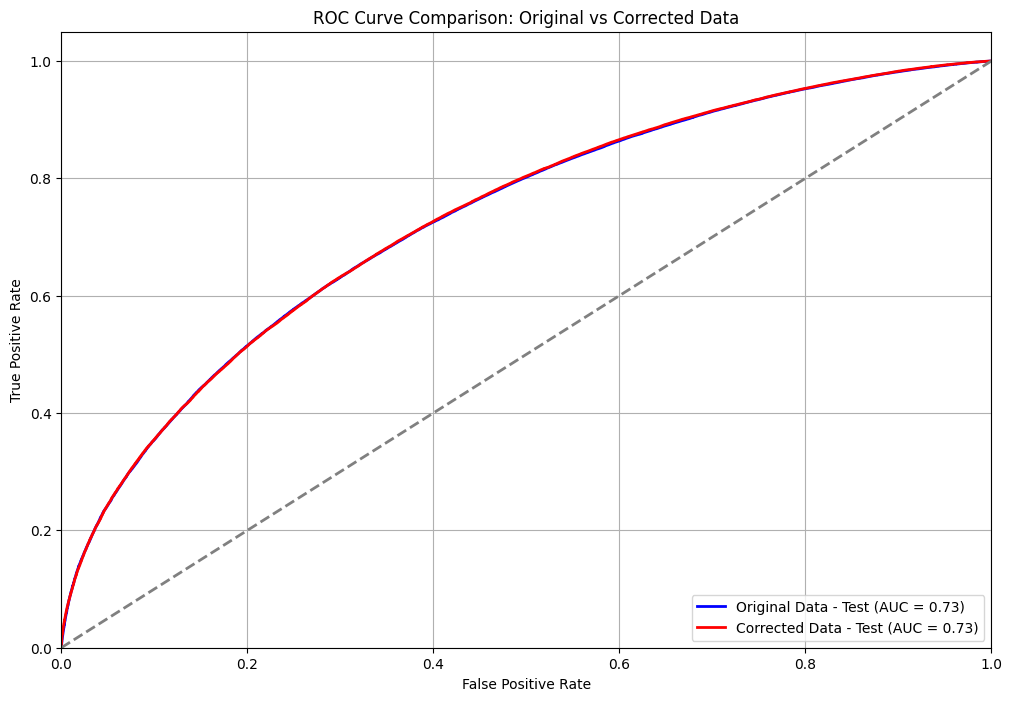

In [3]:
# TRAINING AND EVALUATING USER-CENTERED MODELS
!pip install xgboost==1.7.6 scikit-learn==1.2.2

import zipfile
import io
import pandas as pd
import joblib
import os
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

def prepare_features(df):
    """Prepare feature sets from dataframe"""
    all_features = df.columns.tolist()
    all_features.remove('status')
    all_features.remove('pkgname')

    user_centered_features = all_features.copy()
    developer_centered_features = [f for f in all_features if f not in [
        'FourStarRatings', 'ThreeStarRatings', 'FiveStarRatings',
        'OneStarRatings', 'TwoStarRatings', 'ReviewsAverage',
        'LenWhatsNew', 'max_downloads_log', 'days_since_last_update', 'LastUpdated'
    ]]

    return user_centered_features, developer_centered_features

def clean_dataframe(df):
    """Clean NaN values from dataframe"""
    df_clean = df.dropna(subset=['status'])

    numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns
    categorical_columns = df_clean.select_dtypes(include=['object']).columns

    for col in numeric_columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    for col in categorical_columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    return df_clean

def generate_splits(df, features, random_state=42):
    """Generate training and test splits"""
    df_clean = clean_dataframe(df)

    X = df_clean[features]
    y = df_clean['status']

    # Main train/test split (70/30)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=random_state
    )

    # Create balanced training subset (2K samples)
    n_samples = min(2000, len(y_train) // 2)  # Ensure we don't exceed available samples
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]

    np.random.seed(random_state)
    selected_pos = np.random.choice(pos_idx, n_samples, replace=False)
    selected_neg = np.random.choice(neg_idx, n_samples, replace=False)

    balanced_idx = np.concatenate([selected_pos, selected_neg])
    X_balanced = X_train.iloc[balanced_idx]
    y_balanced = y_train.iloc[balanced_idx]

    return {
        'train': (X_train, y_train),
        'test': (X_test, y_test),
        'balanced': (X_balanced, y_balanced)
    }

def train_models(X, y, features, categorical_features):
    """Train XGBoost models"""
    numerical_features = [f for f in features if f not in categorical_features]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    xgb_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(enable_categorical=True, tree_method='hist'))
    ])

    models = []
    n_classifiers = 11
    max_depth_values = [2, 3]
    n_trees_values = [256, 512]

    for _ in range(n_classifiers):
        max_depth = np.random.choice(max_depth_values)
        n_trees = np.random.choice(n_trees_values)
        model = xgb_pipeline.set_params(
            classifier__n_estimators=n_trees,
            classifier__max_depth=max_depth,
            classifier__random_state=42
        )
        model.fit(X, y)
        models.append(model)

    return models

def evaluate_models(models, X, y, set_name):
    """Evaluate models and return metrics"""
    y_preds = [model.predict_proba(X)[:, 1] for model in models]
    y_pred = np.mean(y_preds, axis=0)
    fpr, tpr, _ = roc_curve(y, y_pred)
    auc_score = auc(fpr, tpr)
    print(f'User-centered Model AUC on {set_name} set: {auc_score:.3f}')
    return fpr, tpr, auc_score

def plot_comparison(results_original, results_corrected, filename='roc_comparison.png'):
    """Plot ROC curves for both datasets"""
    plt.figure(figsize=(12, 8))

    # Plot original data results
    plt.plot(results_original['test_fpr'], results_original['test_tpr'],
             color='blue', lw=2, label=f'Original Data - Test (AUC = {results_original["test_auc"]:.2f})')

    # Plot corrected data results
    plt.plot(results_corrected['test_fpr'], results_corrected['test_tpr'],
             color='red', lw=2, label=f'Corrected Data - Test (AUC = {results_corrected["test_auc"]:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison: Original vs Corrected Data')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Main execution
if __name__ == "__main__":
    # Load both datasets
    df_original = pd.read_csv('/content/sample_data/mergedfeaturessep102.csv')
    df_corrected = pd.read_csv('/content/sample_data/corrected_permacts.csv')

    # Print initial data info
    print("\nOriginal Dataset Info:")
    print(f"Total rows: {len(df_original)}")
    print(f"NaN in status: {df_original['status'].isna().sum()}")

    print("\nCorrected Dataset Info:")
    print(f"Total rows: {len(df_corrected)}")
    print(f"NaN in status: {df_corrected['status'].isna().sum()}")

    # Prepare features (same for both datasets)
    user_features, dev_features = prepare_features(df_original)
    categorical_features = ['Genre', 'ContentRating', 'AndroidVersion',
                          'DeveloperCategory', 'CurrentVersion',
                          'lowest_android_version', 'highest_android_version']

    # Feature verification
    print("\nFeature verification:")
    print("Total features:", len(user_features))
    print("'status' in features:", 'status' in user_features)
    print("First few features:", user_features[:5])

    # Generate splits for both datasets using same random state
    splits_original = generate_splits(df_original, user_features, random_state=42)
    splits_corrected = generate_splits(df_corrected, user_features, random_state=42)

    # Train and evaluate original data models
    original_models = train_models(
        splits_original['balanced'][0],
        splits_original['balanced'][1],
        user_features,
        categorical_features
    )

    original_test_fpr, original_test_tpr, original_test_auc = evaluate_models(
        original_models, splits_original['test'][0], splits_original['test'][1], "test (original)"
    )

    # Train and evaluate corrected data models
    corrected_models = train_models(
        splits_corrected['balanced'][0],
        splits_corrected['balanced'][1],
        user_features,
        categorical_features
    )

    corrected_test_fpr, corrected_test_tpr, corrected_test_auc = evaluate_models(
        corrected_models, splits_corrected['test'][0], splits_corrected['test'][1], "test (corrected)"
    )

    # Prepare results for plotting
    results_original = {
        'test_fpr': original_test_fpr,
        'test_tpr': original_test_tpr,
        'test_auc': original_test_auc
    }

    results_corrected = {
        'test_fpr': corrected_test_fpr,
        'test_tpr': corrected_test_tpr,
        'test_auc': corrected_test_auc
    }

    # Plot comparison
    plot_comparison(results_original, results_corrected)


Training and evaluating developer-centered models...
User-centered Model AUC on test (original developer-centered) set: 0.727
User-centered Model AUC on test (corrected developer-centered) set: 0.719


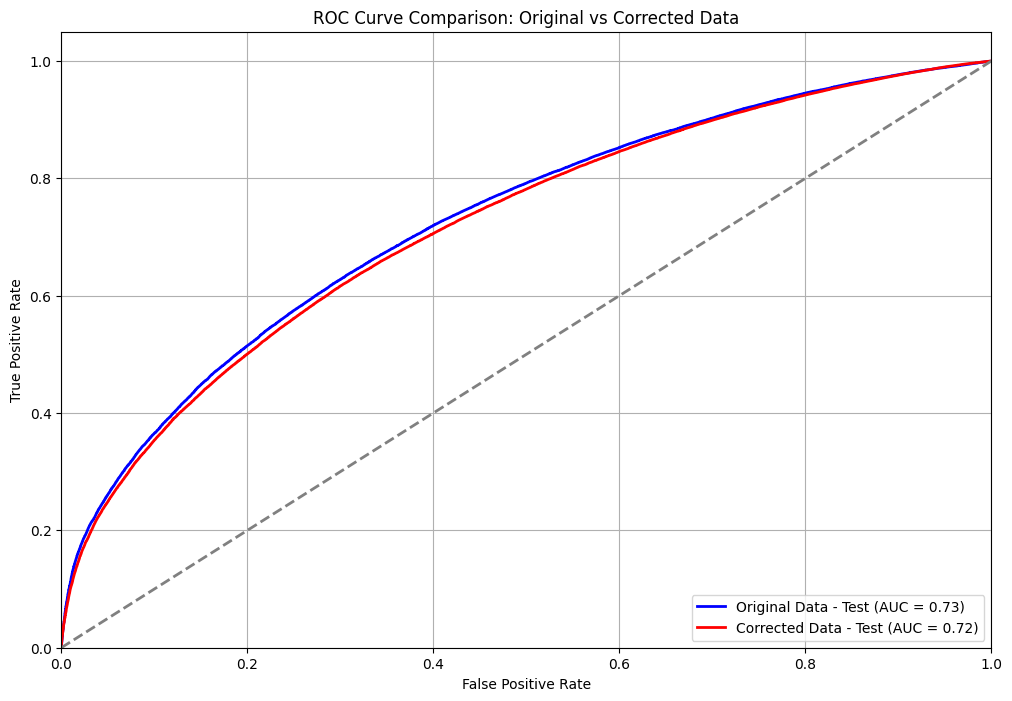

In [4]:
# TRAIN AND EVALUATE DEVELOPER-CENTERED MODEL

# Train and evaluate developer-centered models using the same test splits
print("\nTraining and evaluating developer-centered models...")

# Prepare developer features for both datasets
dev_X_original = splits_original['test'][0][dev_features]
dev_y_original = splits_original['test'][1]
dev_X_balanced_original = splits_original['balanced'][0][dev_features]
dev_y_balanced_original = splits_original['balanced'][1]

dev_X_corrected = splits_corrected['test'][0][dev_features]
dev_y_corrected = splits_corrected['test'][1]
dev_X_balanced_corrected = splits_corrected['balanced'][0][dev_features]
dev_y_balanced_corrected = splits_corrected['balanced'][1]

# Train developer-centered models on original data
original_dev_models = train_models(
    dev_X_balanced_original,
    dev_y_balanced_original,
    dev_features,
    categorical_features
)

# Evaluate on original test set
original_dev_test_fpr, original_dev_test_tpr, original_dev_test_auc = evaluate_models(
    original_dev_models, dev_X_original, dev_y_original, "test (original developer-centered)"
)

# Train and evaluate developer-centered models on corrected data
corrected_dev_models = train_models(
    dev_X_balanced_corrected,
    dev_y_balanced_corrected,
    dev_features,
    categorical_features
)

# Evaluate on corrected test set
corrected_dev_test_fpr, corrected_dev_test_tpr, corrected_dev_test_auc = evaluate_models(
    corrected_dev_models, dev_X_corrected, dev_y_corrected, "test (corrected developer-centered)"
)

# Prepare results for plotting
results_original_dev = {
    'test_fpr': original_dev_test_fpr,
    'test_tpr': original_dev_test_tpr,
    'test_auc': original_dev_test_auc
}

results_corrected_dev = {
    'test_fpr': corrected_dev_test_fpr,
    'test_tpr': corrected_dev_test_tpr,
    'test_auc': corrected_dev_test_auc
}

# Plot comparison for developer-centered models
plot_comparison(results_original_dev, results_corrected_dev, filename='roc_comparison_dev.png')

Feature importance shape: (200,)
Number of feature names: 200


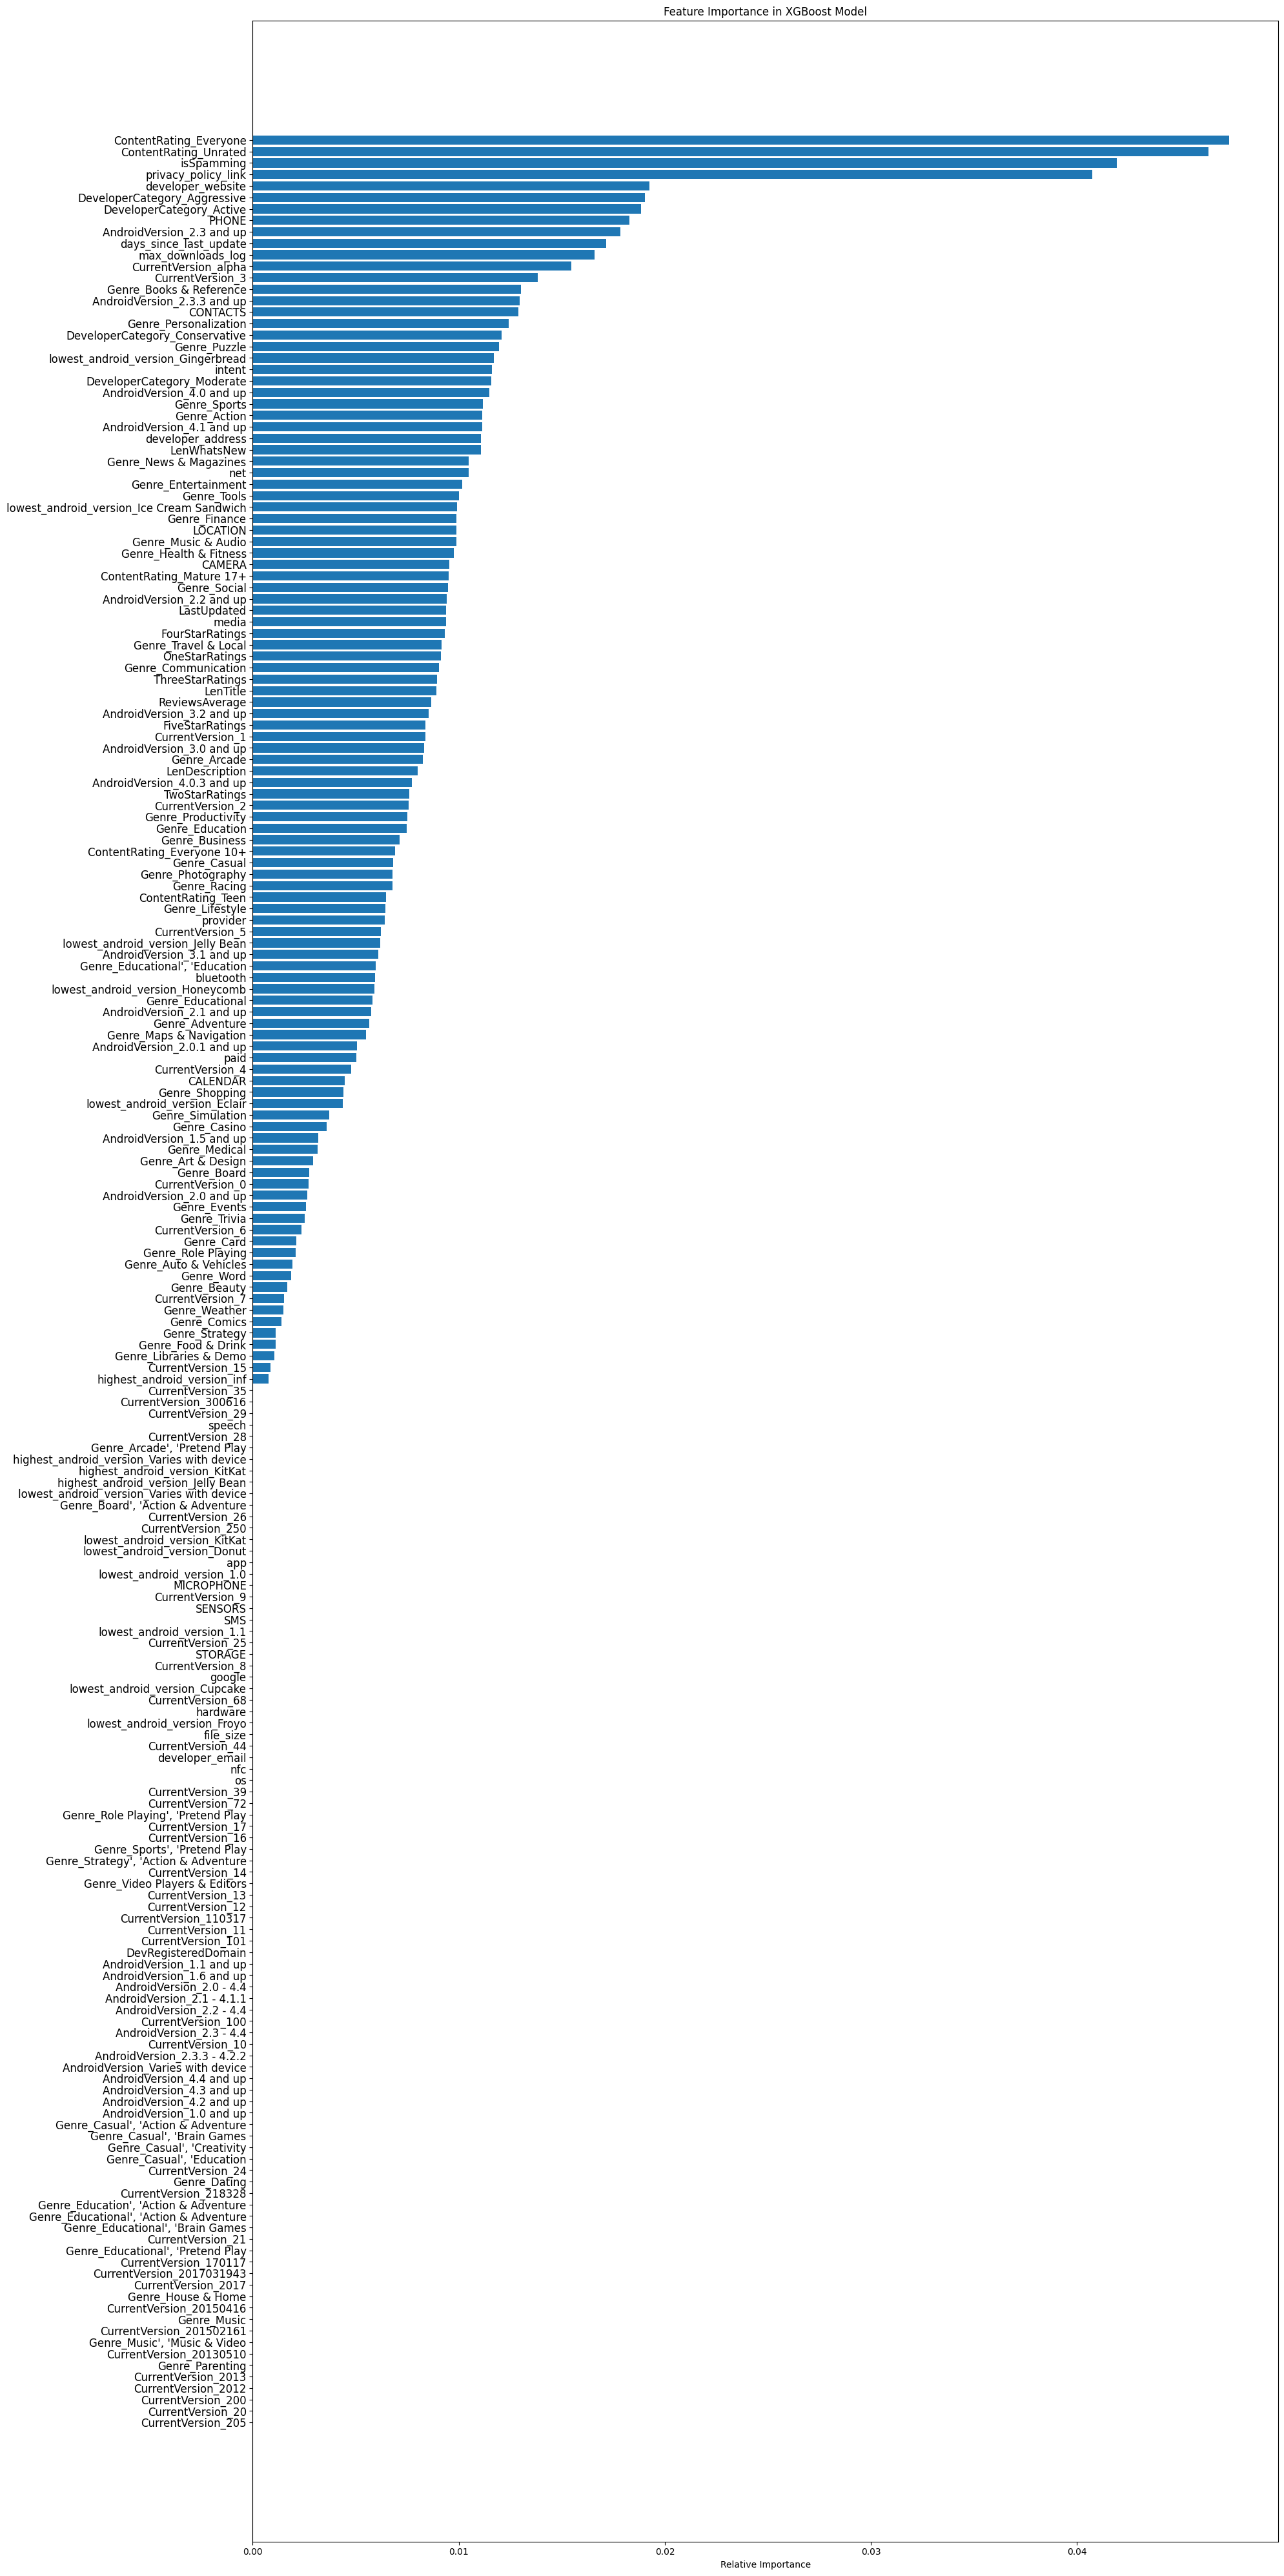


Top 10 most important features:
ContentRating_Everyone: 0.0474
ContentRating_Unrated: 0.0464
isSpamming: 0.0419
privacy_policy_link: 0.0407
developer_website: 0.0193
DeveloperCategory_Aggressive: 0.0190
DeveloperCategory_Active: 0.0189
PHONE: 0.0183
AndroidVersion_2.3 and up: 0.0178
days_since_last_update: 0.0172


In [ ]:
# FEATURE IMPORTANCE
# Get the correct shape from the model
numerical_features = [f for f in user_features if f not in categorical_features]

user_models = original_models
first_model = user_models[0]
xgb_feature_importance = first_model.named_steps['classifier'].feature_importances_
feature_importance = np.zeros_like(xgb_feature_importance)  # Initialize with correct shape

for model in user_models:
   # Get feature importance from the XGBoost classifier
   xgb_feature_importance = model.named_steps['classifier'].feature_importances_
   # Accumulate feature importance
   feature_importance += xgb_feature_importance

# Average feature importance across all models
feature_importance /= len(user_models)

# Map feature importance back to original features
preprocessor = user_models[0].named_steps['preprocessor']
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(cat_feature_names)

# Verify dimensions match
print(f"Feature importance shape: {feature_importance.shape}")
print(f"Number of feature names: {len(feature_names)}")

# Create a dictionary of feature importances
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_idx = np.argsort(feature_importance)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = feature_importance[sorted_idx]

# Plot feature importance
plt.figure(figsize=(20, 40))  # Increased height to better show labels
plt.barh(range(len(sorted_importance)), sorted_importance)
plt.yticks(range(len(sorted_importance)), sorted_features, fontsize=12)
plt.xlabel('Relative Importance')
plt.title('Feature Importance in XGBoost Model')
plt.tight_layout()
plt.show()

# Print top N most important features
N = 10  # Adjust this to show more or fewer features
print(f"\nTop {N} most important features:")
for idx in reversed(sorted_idx[-N:]):
   print(f"{feature_names[idx]}: {feature_importance[idx]:.4f}")

In [ ]:
# LLM-BASED PREDICTION EXPLANATION

In [ ]:
!pip install groq
import base64
import groq
import asyncio
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.1/109.1 kB 10.2 MB/s eta 0:00:00


<Figure size 2500x1500 with 0 Axes>

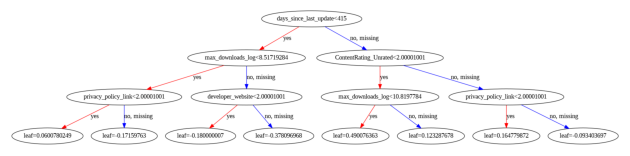

In [ ]:
from xgboost import plot_tree

def visualize_decision_path(models, sample_idx=0):
    """Create a readable decision tree visualization by setting feature names directly"""
    model = models[0].named_steps['classifier']

    # Get feature names
    preprocessor = models[0].named_steps['preprocessor']
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = numerical_features + list(cat_feature_names)

    # Set feature names directly on the booster
    model.get_booster().feature_names = feature_names

    plt.figure(figsize=(25, 15))
    plot_tree(model, num_trees=0)
    plt.tight_layout()
    return plt

# Run visualization
plt = visualize_decision_path(user_models)
plt.show()

In [ ]:
def create_feature_contribution_map(models, X_sample):
    """Create a more readable feature contribution heatmap"""
    # Get feature contributions for each model
    contributions = []

    for model in models:
        X_transformed = model.named_steps['preprocessor'].transform(X_sample)
        contribution = model.named_steps['classifier'].feature_importances_
        contributions.append(contribution)

    # Average contributions across models
    avg_contribution = np.mean(contributions, axis=0)

    # Get feature names
    preprocessor = models[0].named_steps['preprocessor']
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = numerical_features + list(cat_feature_names)

    # Sort features by contribution magnitude
    sorted_indices = np.argsort(np.abs(avg_contribution))
    top_n = 20  # Show only top 20 most important features

    selected_indices = sorted_indices[-top_n:]
    selected_contributions = avg_contribution[selected_indices]
    selected_features = [feature_names[i] for i in selected_indices]

    # Create contribution map
    plt.figure(figsize=(15, 8))
    plt.barh(range(len(selected_contributions)), selected_contributions)

    # Customize appearance
    plt.yticks(range(len(selected_features)), selected_features, fontsize=10)
    plt.xlabel('Feature Contribution', fontsize=12)
    plt.title('Top Feature Contributions', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Color positive and negative contributions differently
    colors = ['red' if x < 0 else 'blue' for x in selected_contributions]
    plt.barh(range(len(selected_contributions)), selected_contributions, color=colors)

    # Add value labels on the bars
    for i, v in enumerate(selected_contributions):
        plt.text(v, i, f'{v:.3f}',
                va='center',
                fontsize=8,
                fontweight='bold')

    plt.tight_layout()
    return plt

# Generate and visualize feature contribution map
plt = create_feature_contribution_map(user_models, X_test.iloc[[0]])
plt.show()

NameError: name 'X_test' is not defined

In [ ]:
import google.generativeai as genai
from google.colab import userdata
genai.configure(api_key=userdata.get('GEMINI_API_KEY'))

def visualize_decision_path(models, sample_idx):
    """Create a readable decision tree visualization by setting feature names directly"""
    model = models[0].named_steps['classifier']

    # Get feature names
    preprocessor = models[0].named_steps['preprocessor']
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = numerical_features + list(cat_feature_names)

    # Set feature names directly on the booster
    model.get_booster().feature_names = feature_names

    plt.figure(figsize=(25, 15))
    plot_tree(model, num_trees=0)
    plt.tight_layout()
    return plt

def save_visualizations(models, X_sample, sample_idx, output_dir='explanation_plots'):
    """Save decision tree and feature importance visualizations"""
    os.makedirs(output_dir, exist_ok=True)

    # Generate and save decision tree plot
    plt = visualize_decision_path(models, sample_idx)
    tree_path = os.path.join(output_dir, 'decision_tree.png')
    plt.savefig(tree_path)
    plt.close()

    # Generate and save feature contribution map
    plt = create_feature_contribution_map(models, X_sample)
    contrib_path = os.path.join(output_dir, 'feature_contribution.png')
    plt.savefig(contrib_path)
    plt.close()

    # Get feature names
    preprocessor = models[0].named_steps['preprocessor']
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = numerical_features + list(cat_feature_names)

    return {
        'decision_tree': tree_path,
        'contribution_map': contrib_path
    }, feature_names

def generate_model_explanation(models, X_sample, sample_idx):
    """Generate explanation using Gemini Flash"""
    from google.generativeai import GenerativeModel
    import PIL.Image

    # Generate and save visualizations
    viz_paths, feature_names = save_visualizations(models, X_sample, sample_idx)

    # Get prediction
    y_pred = np.mean([model.predict_proba(X_sample)[:, 1] for model in models])

    # Get feature contributions
    contributions = []
    for model in models:
        X_transformed = model.named_steps['preprocessor'].transform(X_sample)
        contribution = model.named_steps['classifier'].feature_importances_
        contributions.append(contribution)
    avg_contribution = np.mean(contributions, axis=0)

    # Get top features
    sorted_features = sorted(
        zip(feature_names, avg_contribution),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:5]

    # Create prompt
    prompt = f"""You are an expert ML model interpreter. You're tasked with explaining an XGBoost model's decision
    path and feature importance plots for malware detection, where the model predicts if an app is malicious (1) or benign (0).

    The model predicted a score of {y_pred:.3f} (higher values indicate higher likelihood of malware).

    The top 5 most influential features were:
    {sorted_features}

    In your response:
    - Explain what features the model is focusing on most heavily based on the feature importance plot
    - Explain what decision path the model took to reach its prediction, based on the decision tree visualization
    - Explain possible reasons why the model made the prediction it did
    - Keep your explanation to 4 sentences max"""

    # Load images
    tree_img = PIL.Image.open(viz_paths['decision_tree'])
    feat_img = PIL.Image.open(viz_paths['contribution_map'])

    # Get explanation from Gemini
    model = GenerativeModel(model_name='gemini-1.5-flash')
    response = model.generate_content([prompt, tree_img, feat_img])

    return response.text, y_pred

def explain_prediction(models, X_sample, sample_idx):
    """Wrapper to get and print model explanation"""
    try:
        explanation, y_pred = generate_model_explanation(models, X_sample, sample_idx)
        print(f"Prediction: {y_pred:.3f}")
        print("\nModel Explanation:")
        print("-" * 80)
        # print(explanation)
        return explanation, y_pred
    except Exception as e:
        print(f"Error getting explanation: {e}")
        return None, None

# Get explanation for a sample
sample_idx = 1
# print(X_train.iloc[sample_idx])
X_sample = X_test.iloc[[sample_idx]]
explain_prediction(user_models, X_sample, sample_idx)

NameError: name 'X_test' is not defined

In [9]:
!pip install category_encoders scikit-learn pandas torch numpy tomli_w tomli zero

# %%
import math
import typing as ty
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as nn_init
from torch import Tensor

import lib


def attenuated_kaiming_uniform_(tensor, a=math.sqrt(5), scale=1., mode='fan_in', nonlinearity='leaky_relu'):
    fan = nn_init._calculate_correct_fan(tensor, mode)
    gain = nn_init.calculate_gain(nonlinearity, a)
    std = gain * scale / math.sqrt(fan)
    bound = math.sqrt(3.0) * std  # Calculate uniform bounds from standard deviation
    with torch.no_grad():
        return tensor.uniform_(-bound, bound)

# def attenuated_init(tensor: Tensor, activation='none', scale=1.):
#     if activation in ['relu', 'tanh', 'sigmoid']:
#         nn_init.xavier_uniform_(tensor, gain=nn_init.calculate_gain(activation) * scale)
#     elif activation == 'attention':
#         nn_init.xavier_uniform_(tensor, gain=1 / math.sqrt(2) * scale)
#     else:
#         nn_init.xavier_uniform_(tensor, gain=1.0 * scale)


class Tokenizer(nn.Module):
    category_offsets: ty.Optional[Tensor]

    def __init__(
        self,
        d_numerical: int,
        categories: ty.Optional[ty.List[int]],
        d_token: int,
        bias: bool,
    ) -> None:
        super().__init__()
        print(f"d_numerical: {d_numerical}")
        print(f"categories: {categories}")
        print(f"d_token: {d_token}")
        print(f"bias: {bias}")

        if categories is None:
            d_bias = d_numerical
            self.category_offsets = None
            self.category_embeddings = None
        else:
            d_bias = d_numerical + len(categories)
            category_offsets = torch.tensor([0] + categories[:-1]).cumsum(0)
            self.register_buffer('category_offsets', category_offsets)
            self.category_embeddings = nn.Embedding(sum(categories), d_token)
            nn_init.kaiming_uniform_(self.category_embeddings.weight, a=math.sqrt(5))
            print(f'{self.category_embeddings.weight.shape}')

        print(f'category_embeddings.weight.shape: {self.category_embeddings.weight.shape}')
        print(f"d_bias: {d_bias}")

        self.weight = nn.Parameter(Tensor(d_numerical, d_token))
        self.weight2 = nn.Parameter(Tensor(d_numerical, d_token))
        self.bias = nn.Parameter(Tensor(d_bias, d_token)) if bias else None
        self.bias2 = nn.Parameter(Tensor(d_bias, d_token)) if bias else None

        print(f"weight.shape: {self.weight.shape}")
        print(f"weight2.shape: {self.weight2.shape}")
        print(f"bias.shape: {self.bias.shape if self.bias is not None else None}")
        print(f"bias2.shape: {self.bias2.shape if self.bias2 is not None else None}")

        # v4
        attenuated_kaiming_uniform_(self.weight)
        attenuated_kaiming_uniform_(self.weight2)
        nn_init.kaiming_uniform_(self.bias, a=math.sqrt(5))
        nn_init.kaiming_uniform_(self.bias2, a=math.sqrt(5))


    @property
    def n_tokens(self) -> int:
        return len(self.weight) + (
            0 if self.category_offsets is None else len(self.category_offsets)
        )

    def forward(self, x_num: Tensor) -> Tensor:
        x_some = x_num
        assert x_some is not None
        print(f"x_num shape: {x_num.shape}")
        print(f"self.weight shape: {self.weight.shape}")
        print(f"self.bias shape: {self.bias.shape}")
        x1 = self.weight[None] * x_num[:, :, None] + self.bias[None]
        x2 = self.weight2[None] * x_num[:, :, None] + self.bias2[None]
        return x1 * torch.tanh(x2)


class MultiheadAttention(nn.Module):
    def __init__(
        self, d: int, n_heads: int, dropout: float, init_scale: float = 0.01
    ) -> None:
        if n_heads > 1:
            assert d % n_heads == 0
        # assert initialization in ['xavier', 'kaiming']

        super().__init__()
        self.W_q = nn.Linear(d, d)
        self.W_k = nn.Linear(d, d)
        self.W_v = nn.Linear(d, d)
        self.W_out = nn.Linear(d, d) if n_heads > 1 else None
        self.n_heads = n_heads
        self.dropout = nn.Dropout(dropout) if dropout else None

        for i, m in enumerate([self.W_q, self.W_k, self.W_v]):
            # all small
            attenuated_kaiming_uniform_(m.weight, scale=init_scale)
            nn_init.zeros_(m.bias)
        if self.W_out is not None:
            attenuated_kaiming_uniform_(self.W_out.weight)
            nn_init.zeros_(self.W_out.bias)

    def _reshape(self, x: Tensor) -> Tensor:
        batch_size, n_tokens, d = x.shape
        d_head = d // self.n_heads
        return (
            x.reshape(batch_size, n_tokens, self.n_heads, d_head)
            .transpose(1, 2)
            .reshape(batch_size * self.n_heads, n_tokens, d_head)
        )

    def get_attention_mask(self, input_shape, device):
        bs, _, seq_len = input_shape
        seq_ids = torch.arange(seq_len, device=device)
        attention_mask = seq_ids[None, None, :].repeat(bs, seq_len, 1) <= seq_ids[None, :, None]
        # attention_mask = seq_ids[None, :].repeat(seq_len, 1) <= seq_ids[:, None]
        attention_mask = (1.0 - attention_mask.float()) * -1e4
        return attention_mask

    def forward(
        self,
        x_q: Tensor,
        x_kv: Tensor,
        key_compression: ty.Optional[nn.Linear],
        value_compression: ty.Optional[nn.Linear],
    ) -> Tensor:
        q, k, v = self.W_q(x_q), self.W_k(x_kv), self.W_v(x_kv)
        for tensor in [q, k, v]:
            assert tensor.shape[-1] % self.n_heads == 0
        if key_compression is not None:
            assert value_compression is not None
            k = key_compression(k.transpose(1, 2)).transpose(1, 2)
            v = value_compression(v.transpose(1, 2)).transpose(1, 2)
        else:
            assert value_compression is None

        batch_size = len(q)
        d_head_key = k.shape[-1] // self.n_heads
        d_head_value = v.shape[-1] // self.n_heads
        n_q_tokens = q.shape[1]

        q = self._reshape(q)
        k = self._reshape(k)
        attention_scores = q @ k.transpose(1, 2) / math.sqrt(d_head_key) # b f f
        masks = self.get_attention_mask(attention_scores.shape, attention_scores.device)
        attention = F.softmax(attention_scores + masks, dim=-1)
        if self.dropout is not None:
            attention = self.dropout(attention)
        x = attention @ self._reshape(v)
        x = (
            x.reshape(batch_size, self.n_heads, n_q_tokens, d_head_value)
            .transpose(1, 2)
            .reshape(batch_size, n_q_tokens, self.n_heads * d_head_value)
        )
        if self.W_out is not None:
            x = self.W_out(x)
        return x


class ExcelFormer(nn.Module):
    """ExcelFormer with All initialized by small value

    initial function: v4
    """
    def __init__(
        self,
        *,
        # tokenizer
        d_numerical: int,
        categories: ty.Optional[ty.List[int]],
        token_bias: bool,
        # transformer
        n_layers: int,
        d_token: int,
        n_heads: int,
        attention_dropout: float,
        ffn_dropout: float,
        residual_dropout: float,
        prenormalization: bool,
        # linformer
        kv_compression: ty.Optional[float],
        kv_compression_sharing: ty.Optional[str],
        #
        d_out: int,
        init_scale: float = 0.1,
    ) -> None:
        assert (kv_compression is None) ^ (kv_compression_sharing is not None)

        super().__init__()
        # assert initialization in ['xavier', 'kaiming']
        n_tokens = d_numerical + len(categories) if categories is not None else d_numerical
        self.tokenizer = Tokenizer(d_numerical, categories, d_token, token_bias)
        self.n_categories = 0 if categories is None else len(categories)

        def make_kv_compression():
            assert kv_compression
            compression = nn.Linear(
                n_tokens, int(n_tokens * kv_compression), bias=False
            )
            return compression

        self.shared_kv_compression = (
            make_kv_compression()
            if kv_compression and kv_compression_sharing == 'layerwise'
            else None
        )

        def make_normalization():
            return nn.LayerNorm(d_token)

        self.layers = nn.ModuleList([])
        for layer_idx in range(n_layers):
            layer = nn.ModuleDict(
                {
                    # Attenuated Initialization
                    'attention': MultiheadAttention(
                        d_token, n_heads, attention_dropout, init_scale=init_scale
                    ),
                    'linear0': nn.Linear(d_token, d_token * 2),
                    'norm1': make_normalization(),
                }
            )
            # Attenuated Initialization
            attenuated_kaiming_uniform_(layer['linear0'].weight, scale=init_scale)
            nn_init.zeros_(layer['linear0'].bias)

            if not prenormalization or layer_idx:
                layer['norm0'] = make_normalization()
            if kv_compression and self.shared_kv_compression is None:
                layer['key_compression'] = make_kv_compression()
                if kv_compression_sharing == 'headwise':
                    layer['value_compression'] = make_kv_compression()
                else:
                    assert kv_compression_sharing == 'key-value'
            self.layers.append(layer)

        self.activation = lib.get_activation_fn('tanglu')
        self.last_activation = nn.PReLU()
        self.prenormalization = prenormalization
        self.last_normalization = make_normalization() if prenormalization else None
        self.ffn_dropout = ffn_dropout
        self.residual_dropout = residual_dropout

        # Attenuated Initialization
        self.head = nn.Linear(d_token, d_out)
        attenuated_kaiming_uniform_(self.head.weight)
        # nn_init.zeros_(self.head.bias)
        self.last_fc = nn.Linear(n_tokens, 1) # b f d -> b 1 d
        attenuated_kaiming_uniform_(self.last_fc.weight)
        # nn_init.zeros_(self.last_fc.bias)


    def _get_kv_compressions(self, layer):
        return (
            (self.shared_kv_compression, self.shared_kv_compression)
            if self.shared_kv_compression is not None
            else (layer['key_compression'], layer['value_compression'])
            if 'key_compression' in layer and 'value_compression' in layer
            else (layer['key_compression'], layer['key_compression'])
            if 'key_compression' in layer
            else (None, None)
        )

    def _start_residual(self, x, layer, norm_idx):
        x_residual = x
        if self.prenormalization:
            norm_key = f'norm{norm_idx}'
            if norm_key in layer:
                x_residual = layer[norm_key](x_residual)
        return x_residual

    def _end_residual(self, x, x_residual, layer, norm_idx):
        if self.residual_dropout:
            x_residual = F.dropout(x_residual, self.residual_dropout, self.training)
        x = x + x_residual
        if not self.prenormalization:
            x = layer[f'norm{norm_idx}'](x)
        return x

    def forward(self, x_num: Tensor, x_cat: ty.Optional[Tensor], mixup: bool=False, beta=0.5, mtype='feat_mix') -> Tensor:
        assert x_cat is not None
        if mtype == 'niave_mix': # naive mixup
            x_num, feat_masks, shuffled_ids = lib.mixup_data(x_num, beta=beta)
        x = self.tokenizer(x_num) # TODO: replace with PWE  b. f -> b,f ,d
        if mixup and mtype != 'niave_mix':
            mixup_func = {
                'feat_mix': lib.batch_feat_shuffle,
                'hidden_mix': lib.batch_dim_shuffle,
            }[mtype]
            x, feat_masks, shuffled_ids = mixup_func(x, beta=beta)

        for layer_idx, layer in enumerate(self.layers):
            layer = ty.cast(ty.Dict[str, nn.Module], layer)

            x_residual = self._start_residual(x, layer, 0)
            x_residual = layer['attention'](
                x_residual,
                x_residual,
                *self._get_kv_compressions(layer),
            )
            x = self._end_residual(x, x_residual, layer, 0)

            # reglu
            x_residual = self._start_residual(x, layer, 1)
            x_residual = layer['linear0'](x_residual)
            x_residual = self.activation(x_residual)
            x = self._end_residual(x, x_residual, layer, 1)

        x = self.last_fc(x.transpose(1,2))[:,:,0] # b f d -> b d
        if self.last_normalization is not None:
            x = self.last_normalization(x)
        x = self.last_activation(x) # TODO: before last_fc？
        x = self.head(x)
        x = x.squeeze(-1)

        if mixup:
            return x, feat_masks, shuffled_ids
        return x

In [10]:
# Import required libraries

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import math
import os
import sys
from pathlib import Path

# Clone ExcelFormer repository if not already present
if not os.path.exists('ExcelFormer'):
    !git clone https://github.com/WhatAShot/ExcelFormer.git

# Add ExcelFormer to Python path
repo_path = str(Path('ExcelFormer').absolute())
if repo_path not in sys.path:
    sys.path.append(repo_path)

# Import ExcelFormer implementation
# from ExcelFormer.bin.excel_former import ExcelFormer
from ExcelFormer.lib import get_activation_fn

# Read and process the data
df = pd.read_csv('/content/sample_data/corrected_permacts.csv', index_col=0)

# Identify categorical and numerical columns
categorical_columns = [
    'Genre', 'ContentRating', 'CurrentVersion', 'AndroidVersion',
    'DeveloperCategory', 'lowest_android_version', 'highest_android_version'
]
numerical_columns = [col for col in df.columns if col not in categorical_columns + ['status', 'pkgname']]

# Process categorical features
label_encoders = {}
cat_cardinalities = []  # Store number of unique values for each categorical feature
encoded_cat_features = []

for col in categorical_columns:
    le = LabelEncoder()
    encoded_features = le.fit_transform(df[col].astype(str))
    encoded_cat_features.append(encoded_features)
    label_encoders[col] = le
    cat_cardinalities.append(len(le.classes_))
    print(f"Feature {col} has {len(le.classes_)} unique values")

# Convert to numpy arrays
X_cat = np.stack(encoded_cat_features, axis=1)
X_num = df[numerical_columns].values
y = df['status'].values

print(f"Number of numerical columns: {len(numerical_columns)}")
print(f"Numerical features shape: {X_num.shape}")
print(f"Categorical features shape: {X_cat.shape}")

# Split the data
X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_num, X_cat, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_test = scaler.transform(X_num_test)

# Convert to PyTorch tensors
X_num_train_tensor = torch.FloatTensor(X_num_train)
X_cat_train_tensor = torch.LongTensor(X_cat_train)
y_train_tensor = torch.FloatTensor(y_train)

X_num_test_tensor = torch.FloatTensor(X_num_test)
X_cat_test_tensor = torch.LongTensor(X_cat_test)
y_test_tensor = torch.FloatTensor(y_test)

# Create data loaders
train_dataset = TensorDataset(X_num_train_tensor, X_cat_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_num_test_tensor, X_cat_test_tensor, y_test_tensor)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Initialize ExcelFormer model
model = ExcelFormer(
    # Tokenizer settings
    d_numerical=len(numerical_columns),  # Number of numerical features
    categories=cat_cardinalities,  # List of cardinalities for each categorical feature
    token_bias=True,

    # Transformer settings
    n_layers=3,
    d_token=256,
    n_heads=8,
    attention_dropout=0.3,
    ffn_dropout=0.3,
    residual_dropout=0.0,
    prenormalization=True,

    # Linformer settings
    kv_compression=None,
    kv_compression_sharing=None,

    # Output settings
    d_out=1,  # Binary classification
    init_scale=0.1,
)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = model.to(device)

# Set up loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# Training loop
n_epochs = 100
best_test_auc = 0

print("Starting training...")

for epoch in range(n_epochs):
    # Training phase
    model.train()
    train_loss = 0
    for batch_num, batch_cat, batch_y in train_loader:
        batch_num = batch_num.to(device)
        batch_cat = batch_cat.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_num, batch_cat)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Evaluation phase
    model.eval()
    test_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch_num, batch_cat, batch_y in test_loader:
            batch_num = batch_num.to(device)
            batch_cat = batch_cat.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_num, batch_cat)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()

            predictions.extend(torch.sigmoid(outputs).cpu().numpy())
            true_labels.extend(batch_y.cpu().numpy())

    # Calculate AUC
    from sklearn.metrics import roc_auc_score
    test_auc = roc_auc_score(true_labels, predictions)

    # Print metrics
    print(f'Epoch {epoch+1}/{n_epochs}')
    print(f'Train Loss: {train_loss/len(train_loader):.4f}')
    print(f'Test Loss: {test_loss/len(test_loader):.4f}')
    print(f'Test AUC: {test_auc:.4f}')
    print('-'*50)

    # Save best model
    if test_auc > best_test_auc:
        best_test_auc = test_auc
        torch.save(model.state_dict(), 'best_excelformer.pth')

print(f'Best Test AUC: {best_test_auc:.4f}')

Feature Genre has 180 unique values
Feature ContentRating has 6 unique values
Feature CurrentVersion has 2062 unique values
Feature AndroidVersion has 90 unique values
Feature DeveloperCategory has 4 unique values
Feature lowest_android_version has 13 unique values
Feature highest_android_version has 5 unique values
Number of numerical columns: 40
Numerical features shape: (870514, 40)
Categorical features shape: (870514, 7)
d_numerical: 40
categories: [180, 6, 2062, 90, 4, 13, 5]
d_token: 256
bias: True
torch.Size([2360, 256])
category_embeddings.weight.shape: torch.Size([2360, 256])
d_bias: 47
weight.shape: torch.Size([40, 256])
weight2.shape: torch.Size([40, 256])
bias.shape: torch.Size([47, 256])
bias2.shape: torch.Size([47, 256])
Using device: cuda
Starting training...
x_num shape: torch.Size([256, 40])
self.weight shape: torch.Size([40, 256])
self.bias shape: torch.Size([47, 256])


RuntimeError: The size of tensor a (40) must match the size of tensor b (47) at non-singleton dimension 1